Simulation complete.
  Peak plasma TMZ : 0.000 µg/mL
  Peak CSF TMZ    : 0.0000 µg/mL
  Final sensitive : 0.2210 (normalised fraction)
  Final resistant : 0.0137 (normalised fraction)
  Final neurons   : 0.7864 (normalised fraction)


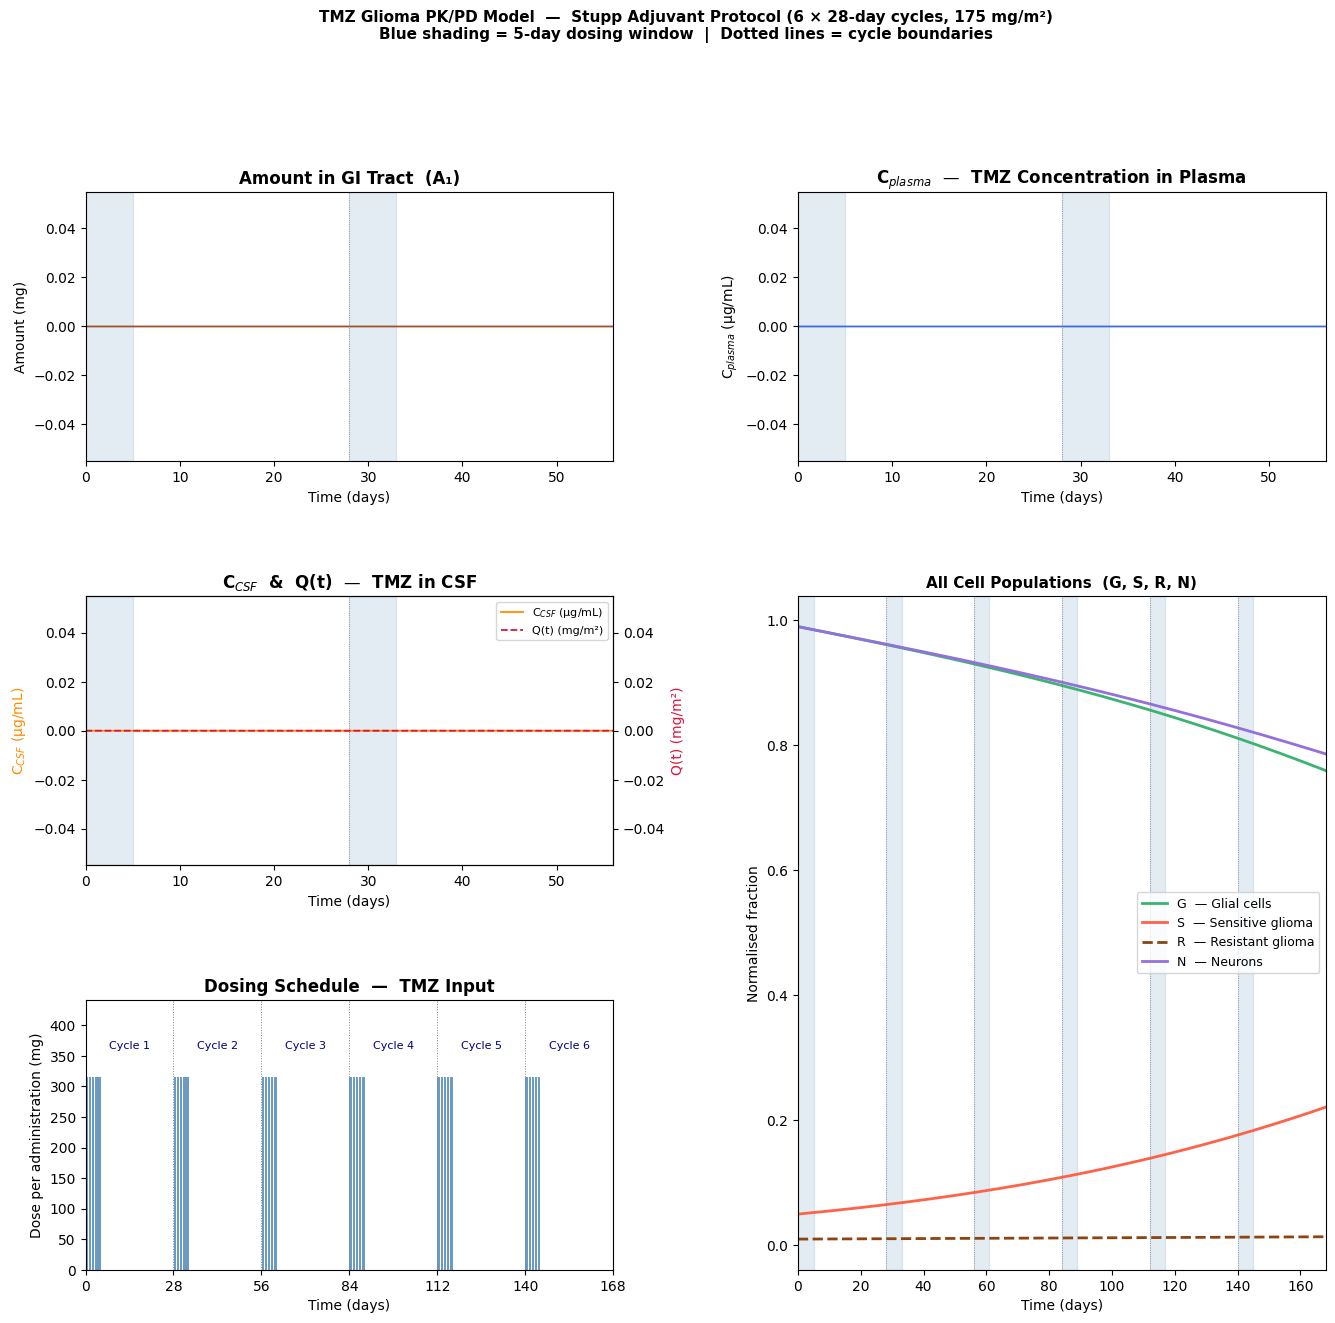

In [22]:
"""
Temozolomide (TMZ) Glioma PK/PD Model
======================================
Combines:
  - 3-compartment PK model (GI tract → Plasma → CSF)
  - Normalised glioma cell population dynamics (glial, sensitive, resistant, neurons)

Dosing: Stupp Protocol (post-radiotherapy adjuvant phase)
  6 cycles × 5 days on / 23 days off, 175 mg/m² per day
  Assumed body surface area (BSA) = 1.8 m² → dose = 315 mg per administration
"""

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ─────────────────────────────────────────────
# PK PARAMETERS
# ─────────────────────────────────────────────
Ka  = 5.8          # h⁻¹  absorption rate constant (GI → plasma)
CL  = 10.0         # L/h  oral clearance
VD  = 30.3         # L    volume of distribution (plasma)
Vp  = 0.14         # L    volume of distribution (CSF)
k23 = 7.2e-4       # h⁻¹  plasma → CSF transfer rate
k32 = 0.14         # h⁻¹  CSF → plasma transfer rate

# ─────────────────────────────────────────────
# DOSING SCHEDULE  (Stupp adjuvant protocol)
# ─────────────────────────────────────────────
BSA          = 1.8          # m²  (typical adult)
DOSE_PER_M2  = 175          # mg/m²
DOSE         = DOSE_PER_M2 * BSA   # mg per administration

N_CYCLES     = 6
DAYS_ON      = 5
CYCLE_LENGTH = 28           # days

# Build list of dose times (hours)
dose_times_h = []
for cycle in range(N_CYCLES):
    cycle_start = cycle * CYCLE_LENGTH * 24   # hours
    for day in range(DAYS_ON):
        dose_times_h.append(cycle_start + day * 24.0)

dose_times_h = np.array(dose_times_h) + 1

T_END_H = N_CYCLES * CYCLE_LENGTH * 24       # total simulation time in hours

# ─────────────────────────────────────────────
# CELL BIOLOGY PARAMETERS  (normalised model)
# ─────────────────────────────────────────────
Pg   = 0.0068 / 24   # day⁻¹ → h⁻¹  glial growth rate
Ps   = 0.012  / 24   # h⁻¹           sensitive glioma growth rate
Pr   = 0.004  / 24   # h⁻¹           resistant glioma growth rate (mid-range)

beta1 = 1.8e-2 / 24  # h⁻¹  glial competition coefficient
beta2 = 1.8e-3 / 24  # h⁻¹  sensitive competition coefficient
beta3 = 1.8e-3 / 24  # h⁻¹  resistant competition coefficient

alpha  = 1.0         # neuronal influence scaling
alpha1 = alpha2 = alpha3 = 1.0

i1 = 4.7e-8          # m²/(mg·h)  chemo effect on glial
i2 = 4.7e-5          # m²/(mg·h)  chemo effect on sensitive glioma
i3 = 4.7e-8          # m²/(mg·h)  chemo effect on neurons

a1 = a2 = a3 = 1.0   # half-saturation constants (normalised)

u  = 0.01            # mutation rate (0–1); fraction of sensitive → resistant per unit Q
zeta = 0.2 / 24      # h⁻¹  drug elimination from tissue

# ─────────────────────────────────────────────
# HELPER FUNCTIONS
# ─────────────────────────────────────────────
def F(x):
    """Heaviside step: 0 if x ≤ 0, else 1."""
    return 1.0 if x > 0 else 0.0

def Q_csf_mgm2(C_csf_ugmL):
    """Convert CSF concentration (µg/mL) → mg/m² using the paper's scaling."""
    return (140.0 / 1800.0) * C_csf_ugmL

def dose_input(t, dose_list, dose_amount, duration=0.5):
    """
    Returns instantaneous infusion rate (mg/h) at time t.
    Each dose is modelled as a short square pulse of `duration` hours.
    """
    for td in dose_list:
        if td <= t < td + duration:
            return dose_amount / duration
    return 0.0

# ─────────────────────────────────────────────
# ODE SYSTEM
# ─────────────────────────────────────────────
def model(t, y):
    A1, A2, A3, g, s, r, n = y

    # ── PK ──────────────────────────────────
    D_rate = dose_input(t, dose_times_h, DOSE)   # mg/h delivered to GI tract

    dA1 = D_rate - Ka * A1
    dA2 = Ka * A1 - (CL / VD) * A2 - k23 * A2 + k32 * A3 * (Vp / 1.0)
    dA3 = k23 * A2 - k32 * A3

    C_plasma = A2 / VD                           # µg/mL  (mg/L ≡ µg/mL)
    C_csf    = A3 / Vp                           # µg/mL
    Q        = Q_csf_mgm2(C_csf)                # mg/m²  — drug in tissue

    # ── Cell dynamics (normalised model) ────
    # Glial cells
    dg = (Pg * g * (1 - g)
          - beta1 * g * (s + r)
          - (i1 * g * Q) / (a1 + g))

    # Sensitive glioma
    ds = (Ps * s * (1 - (s + r))
          - beta2 * g * s
          - u * F(Q) * s
          - (i2 * s * Q) / (a2 + s))

    # Resistant glioma
    dr = (Pr * r * (1 - (s + r))
          - beta3 * g * r
          + u * F(Q) * s)

    # Neurons
    g_dot = (Pg * g * (1 - g)
             - beta1 * g * (s + r)
             - (i1 * g * Q) / (a1 + g))   # reuse dg as g_dot
    dn = (alpha * g_dot * F(-g_dot) * n
          - (i3 * n * Q) / (a3 + n))

    return [dA1, dA2, dA3, dg, ds, dr, dn]

# ─────────────────────────────────────────────
# INITIAL CONDITIONS
# ─────────────────────────────────────────────
# PK compartments start empty
A1_0 = A2_0 = A3_0 = 0.0

# Normalised cell fractions at t=0 (post-radiotherapy state)
g0 = 0.99    # glial cells near carrying capacity
s0 = 0.05   # small residual sensitive tumour
r0 = 0.01   # small resistant population
n0 = 0.99    # neurons somewhat depleted by prior treatment

y0 = [A1_0, A2_0, A3_0, g0, s0, r0, n0]

# ─────────────────────────────────────────────
# SOLVE
# ─────────────────────────────────────────────
t_eval = np.linspace(0, T_END_H, 10_000)

sol = solve_ivp(
    model,
    [0, T_END_H],
    y0,
    method='RK45',
    t_eval=t_eval,
    rtol=1e-8,
    atol=1e-10,
    dense_output=True
)

t_days = sol.t / 24.0
A1, A2, A3, g, s, r, n = sol.y

C_plasma = A2 / VD
C_csf    = A3 / Vp
Q_tissue = Q_csf_mgm2(C_csf)

# ─────────────────────────────────────────────
# PLOTTING
# ─────────────────────────────────────────────

# Show only first 2 cycles for PK plots so dosing fluctuations are clearly visible
PK_ZOOM_DAYS = 2 * CYCLE_LENGTH   # 56 days

cycle_boundaries = [c * CYCLE_LENGTH for c in range(N_CYCLES + 1)]

def shade_cycles(ax, x_end):
    for c in range(N_CYCLES):
        start = c * CYCLE_LENGTH
        if start >= x_end:
            break
        end = min(start + DAYS_ON, x_end)
        ax.axvspan(start, end, alpha=0.15, color='steelblue', label='_nolegend_')

def add_cycle_lines(ax, x_end):
    for cb in cycle_boundaries[1:]:
        if cb <= x_end:
            ax.axvline(cb, color='grey', lw=0.6, ls=':')

fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.50, wspace=0.35)

# ── 1. Amount in GI Tract (A1) ───────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(t_days, A1, color='sienna', lw=1.3)
shade_cycles(ax1, PK_ZOOM_DAYS)
add_cycle_lines(ax1, PK_ZOOM_DAYS)
ax1.set_title('Amount in GI Tract  (A₁)', fontweight='bold')
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Amount (mg)')
ax1.set_xlim(0, PK_ZOOM_DAYS)

# ── 2. Amount in Plasma (A2) → Cplasma ───────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(t_days, C_plasma, color='royalblue', lw=1.3)
shade_cycles(ax2, PK_ZOOM_DAYS)
add_cycle_lines(ax2, PK_ZOOM_DAYS)
ax2.set_title('C$_{plasma}$  —  TMZ Concentration in Plasma', fontweight='bold')
ax2.set_xlabel('Time (days)')
ax2.set_ylabel('C$_{plasma}$ (µg/mL)')
ax2.set_xlim(0, PK_ZOOM_DAYS)

# ── 3. Amount in CSF (A3) → Ccsf & Q(t) ─────
ax3 = fig.add_subplot(gs[1, 0])
ax3_r = ax3.twinx()
ax3.plot(t_days, C_csf,    color='darkorange', lw=1.3, label='C$_{CSF}$ (µg/mL)')
ax3_r.plot(t_days, Q_tissue, color='crimson',  lw=1.3, ls='--', label='Q(t) (mg/m²)')
shade_cycles(ax3, PK_ZOOM_DAYS)
add_cycle_lines(ax3, PK_ZOOM_DAYS)
ax3.set_title('C$_{CSF}$  &  Q(t)  —  TMZ in CSF', fontweight='bold')
ax3.set_xlabel('Time (days)')
ax3.set_ylabel('C$_{CSF}$ (µg/mL)', color='darkorange')
ax3_r.set_ylabel('Q(t) (mg/m²)',     color='crimson')
ax3.set_xlim(0, PK_ZOOM_DAYS)
lines1, labs1 = ax3.get_legend_handles_labels()
lines2, labs2 = ax3_r.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc='upper right')

# ── 4. All cell populations on one graph ─────
ax4 = fig.add_subplot(gs[1:, 1])   # spans rows 1 and 2, right column
ax4.plot(t_days, g, color='mediumseagreen', lw=2.0, label='G  — Glial cells')
ax4.plot(t_days, s, color='tomato',         lw=2.0, label='S  — Sensitive glioma')
ax4.plot(t_days, r, color='saddlebrown',    lw=2.0, label='R  — Resistant glioma', ls='--')
ax4.plot(t_days, n, color='mediumpurple',   lw=2.0, label='N  — Neurons')
shade_cycles(ax4, t_days[-1])
add_cycle_lines(ax4, t_days[-1])
ax4.set_title('All Cell Populations  (G, S, R, N)', fontweight='bold', fontsize=11)
ax4.set_xlabel('Time (days)')
ax4.set_ylabel('Normalised fraction')
ax4.set_xlim(0, t_days[-1])
ax4.legend(fontsize=9, loc='center right')

# ── 5. Dosing schedule bar chart (all 6 cycles) ──
ax5 = fig.add_subplot(gs[2, 0])
dose_day_list = [td / 24.0 for td in dose_times_h]
ax5.bar(dose_day_list, [DOSE] * len(dose_day_list),
        width=0.8, color='steelblue', alpha=0.8, align='edge')
for cb in cycle_boundaries[1:]:
    ax5.axvline(cb, color='grey', lw=0.7, ls=':')
ax5.set_title('Dosing Schedule  —  TMZ Input', fontweight='bold')
ax5.set_xlabel('Time (days)')
ax5.set_ylabel('Dose per administration (mg)')
ax5.set_xlim(0, t_days[-1])
ax5.set_xticks(cycle_boundaries)
ax5.set_ylim(0, DOSE * 1.4)

# Annotate cycle numbers
for c in range(N_CYCLES):
    mid = c * CYCLE_LENGTH + CYCLE_LENGTH / 2
    ax5.text(mid, DOSE * 1.15, f'Cycle {c+1}', ha='center', fontsize=8, color='navy')

fig.suptitle(
    'TMZ Glioma PK/PD Model  —  Stupp Adjuvant Protocol (6 × 28-day cycles, 175 mg/m²)\n'
    'Blue shading = 5-day dosing window  |  Dotted lines = cycle boundaries',
    fontsize=11, fontweight='bold', y=1.01
)


print("Simulation complete.")
print(f"  Peak plasma TMZ : {C_plasma.max():.3f} µg/mL")
print(f"  Peak CSF TMZ    : {C_csf.max():.4f} µg/mL")
print(f"  Final sensitive : {s[-1]:.4f} (normalised fraction)")
print(f"  Final resistant : {r[-1]:.4f} (normalised fraction)")
print(f"  Final neurons   : {n[-1]:.4f} (normalised fraction)")

Simulation complete.
  Peak plasma TMZ : 8.583 µg/mL
  Peak CSF TMZ    : 2.7667 µg/mL
  Final sensitive : 0.0000 (normalised fraction)
  Final resistant : 0.0753 (normalised fraction)
  Final neurons   : 0.8927 (normalised fraction)
[0. 0. 0. ... 0. 0. 0.]


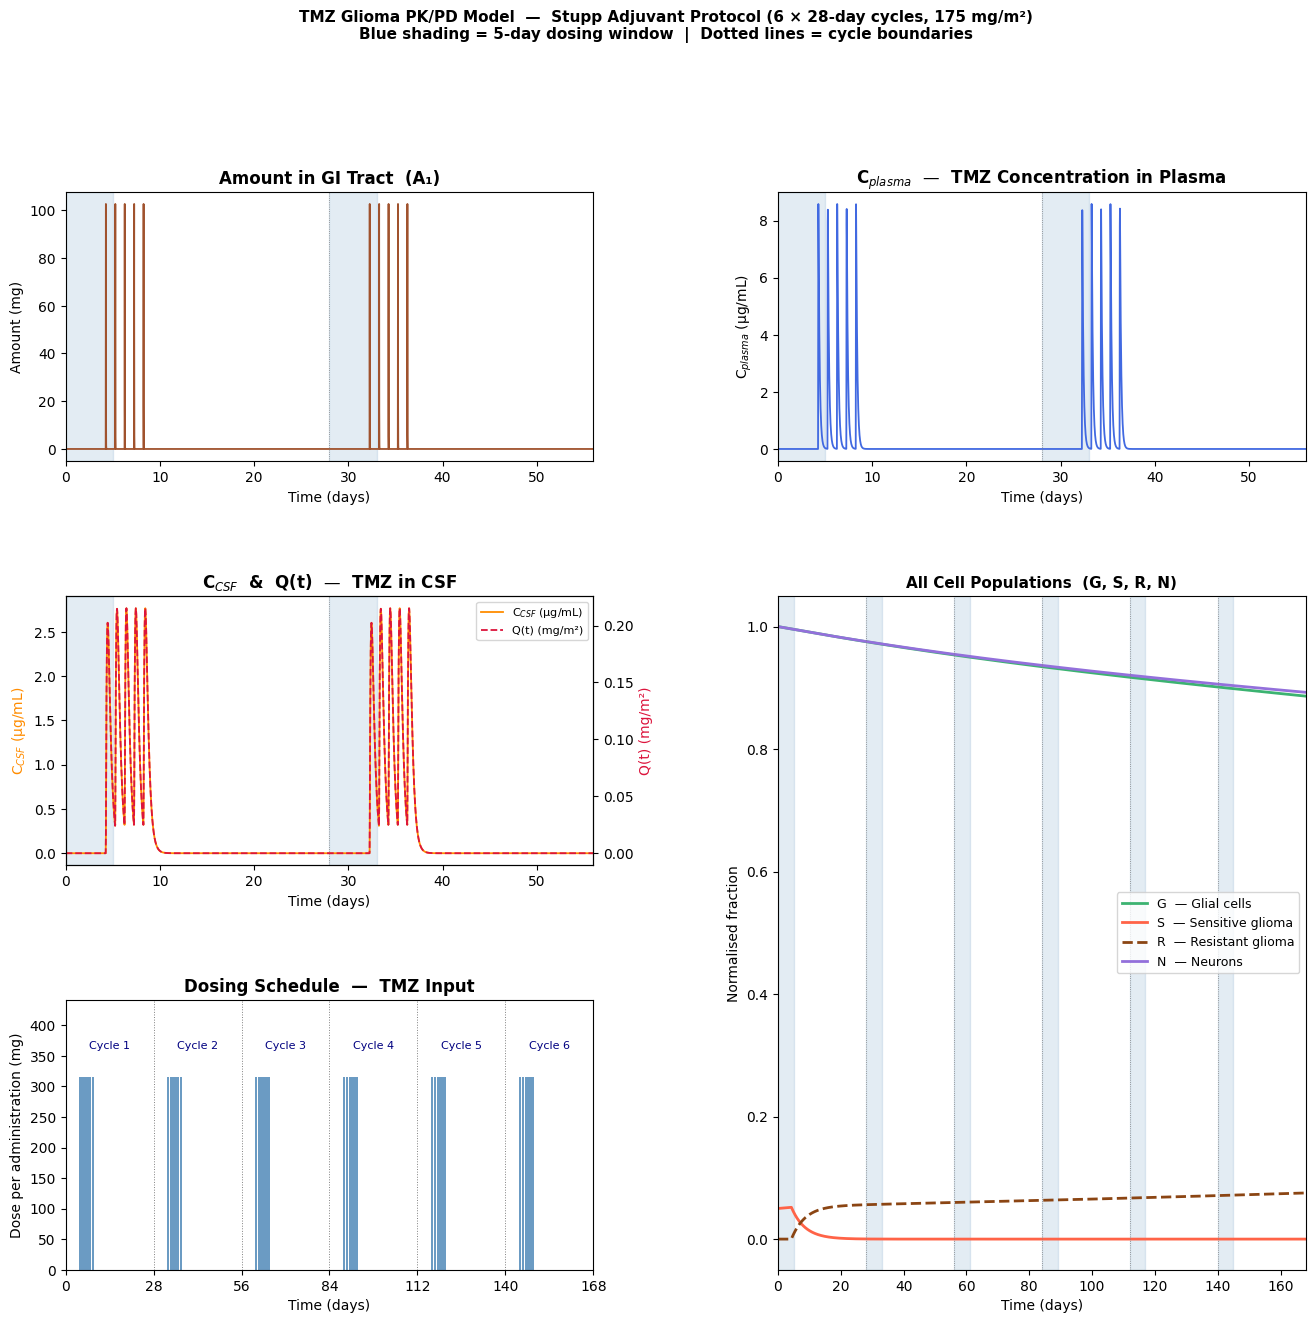

In [29]:
"""
Temozolomide (TMZ) Glioma PK/PD Model
======================================
Combines:
  - 3-compartment PK model (GI tract → Plasma → CSF)
  - Normalised glioma cell population dynamics (glial, sensitive, resistant, neurons)

Dosing: Stupp Protocol (post-radiotherapy adjuvant phase)
  6 cycles × 5 days on / 23 days off, 175 mg/m² per day
  Assumed body surface area (BSA) = 1.8 m² → dose = 315 mg per administration
"""

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ─────────────────────────────────────────────
# PK PARAMETERS
# ─────────────────────────────────────────────
Ka  = 5.8          # h⁻¹  absorption rate constant (GI → plasma)
CL  = 10.0         # L/h  oral clearance
VD  = 30.3         # L    volume of distribution (plasma)
Vp  = 0.14         # L    volume of distribution (CSF)
k23 = 7.2e-4       # h⁻¹  plasma → CSF transfer rate
k32 = 0.14         # h⁻¹  CSF → plasma transfer rate

# ─────────────────────────────────────────────
# DOSING SCHEDULE  (Stupp adjuvant protocol)
# ─────────────────────────────────────────────
BSA          = 1.8          # m²  (typical adult)
DOSE_PER_M2  = 175          # mg/m²
DOSE         = DOSE_PER_M2 * BSA   # mg per administration

N_CYCLES     = 6
DAYS_ON      = 5
CYCLE_LENGTH = 28           # days

# Build list of dose times (hours)
dose_times_h = []
for cycle in range(N_CYCLES):
    cycle_start = cycle * CYCLE_LENGTH * 24   # hours
    for day in range(DAYS_ON):
        dose_times_h.append(cycle_start + day * 24.0)

dose_times_h = np.array(dose_times_h)
T_END_H = N_CYCLES * CYCLE_LENGTH * 24       # total simulation time in hours

# ─────────────────────────────────────────────
# CELL BIOLOGY PARAMETERS  (normalised model)
# ─────────────────────────────────────────────
Pg   = 0.0068 / 24   # day⁻¹ → h⁻¹  glial growth rate
Ps   = 0.012  / 24   # h⁻¹           sensitive glioma growth rate
Pr   = 0.004  / 24   # h⁻¹           resistant glioma growth rate (mid-range)

beta1 = 1.8e-2 / 24  # h⁻¹  glial competition coefficient
beta2 = 1.8e-3 / 24  # h⁻¹  sensitive competition coefficient
beta3 = 1.8e-3 / 24  # h⁻¹  resistant competition coefficient

alpha  = 1.0         # neuronal influence scaling
alpha1 = alpha2 = alpha3 = 1.0

i1 = 4.7e-8          # m²/(mg·h)  chemo effect on glial
i2 = 4.7e-5          # m²/(mg·h)  chemo effect on sensitive glioma
i3 = 4.7e-8          # m²/(mg·h)  chemo effect on neurons

a1 = a2 = a3 = 1.0   # half-saturation constants (normalised)

u  = 0.01            # mutation rate (0–1); fraction of sensitive → resistant per unit Q
zeta = 0.2 / 24      # h⁻¹  drug elimination from tissue

# ─────────────────────────────────────────────
# HELPER FUNCTIONS
# ─────────────────────────────────────────────
def F(x):
    """Heaviside step: 0 if x ≤ 0, else 1."""
    return 1.0 if x > 0 else 0.0

def Q_csf_mgm2(C_csf_ugmL):
    """Convert CSF concentration (µg/mL) → mg/m² using the paper's scaling."""
    return (140.0 / 1800.0) * C_csf_ugmL

def dose_input(t, dose_list, dose_amount, duration=0.5):
    """
    Returns instantaneous infusion rate (mg/h) at time t.
    Each dose is modelled as a short square pulse of `duration` hours.
    """
    for td in dose_list:
        if td <= t < td + duration:
            return dose_amount / duration
    return 0.0

# ─────────────────────────────────────────────
# ODE SYSTEM
# ─────────────────────────────────────────────
def model(t, y):
    A1, A2, A3, g, s, r, n = y

    # ── PK ──────────────────────────────────
    D_rate = dose_input(t, dose_times_h, DOSE)   # mg/h delivered to GI tract

    dA1 = D_rate - Ka * A1
    dA2 = Ka * A1 - (CL / VD) * A2 - k23 * A2 + k32 * A3 * (Vp / 1.0)
    dA3 = k23 * A2 - k32 * A3

    C_plasma = A2 / VD                           # µg/mL  (mg/L ≡ µg/mL)
    C_csf    = A3 / Vp                           # µg/mL
    Q        = Q_csf_mgm2(C_csf)                # mg/m²  — drug in tissue

    # ── Cell dynamics (normalised model) ────
    # Glial cells
    dg = (Pg * g * (1 - g)
          - beta1 * g * (s + r)
          - (i1 * g * Q) / (a1 + g))

    # Sensitive glioma
    ds = (Ps * s * (1 - (s + r))
          - beta2 * g * s
          - u * F(Q) * s
          - (i2 * s * Q) / (a2 + s))

    # Resistant glioma
    dr = (Pr * r * (1 - (s + r))
          - beta3 * g * r
          + u * F(Q) * s)

    # Neurons
    g_dot = (Pg * g * (1 - g)
             - beta1 * g * (s + r)
             - (i1 * g * Q) / (a1 + g))   # reuse dg as g_dot
    dn = (alpha * g_dot * F(-g_dot) * n
          - (i3 * n * Q) / (a3 + n))

    return [dA1, dA2, dA3, dg, ds, dr, dn]

# ─────────────────────────────────────────────
# INITIAL CONDITIONS
# ─────────────────────────────────────────────
# PK compartments start empty
A1_0 = A2_0 = A3_0 = 0.0

# Normalised cell fractions at t=0 (post-radiotherapy state)
g0 = 1    # glial cells near carrying capacity
s0 = 0.05   # small residual sensitive tumour
r0 = 0  # small resistant population
n0 = 1    # neurons somewhat depleted by prior treatment

y0 = [A1_0, A2_0, A3_0, g0, s0, r0, n0]

# ─────────────────────────────────────────────
# SOLVE
# ─────────────────────────────────────────────
t_eval_base = np.linspace(0, T_END_H, 10_000)

# Force evaluation at the start and end of every 0.5h dose window
dose_window_times = np.concatenate([
    dose_times_h,
    np.array(dose_times_h) + 0.5
])

t_eval = np.sort(np.unique(np.concatenate([t_eval_base, dose_window_times])))

sol = solve_ivp(
    model,
    [0, T_END_H],
    y0,
    method='RK45',
    t_eval=t_eval,
    rtol=1e-8,
    atol=1e-10,
    dense_output=True,
    max_step=0.1
)

t_days = sol.t / 24.0
A1, A2, A3, g, s, r, n = sol.y

C_plasma = A2 / VD
C_csf    = A3 / Vp
Q_tissue = Q_csf_mgm2(C_csf)

# ─────────────────────────────────────────────
# PLOTTING
# ─────────────────────────────────────────────

# Show only first 2 cycles for PK plots so dosing fluctuations are clearly visible
PK_ZOOM_DAYS = 2 * CYCLE_LENGTH   # 56 days

cycle_boundaries = [c * CYCLE_LENGTH for c in range(N_CYCLES + 1)]

def shade_cycles(ax, x_end):
    for c in range(N_CYCLES):
        start = c * CYCLE_LENGTH
        if start >= x_end:
            break
        end = min(start + DAYS_ON, x_end)
        ax.axvspan(start, end, alpha=0.15, color='steelblue', label='_nolegend_')

def add_cycle_lines(ax, x_end):
    for cb in cycle_boundaries[1:]:
        if cb <= x_end:
            ax.axvline(cb, color='grey', lw=0.6, ls=':')

fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.50, wspace=0.35)

# ── 1. Amount in GI Tract (A1) ───────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(t_days, A1, color='sienna', lw=1.3)
shade_cycles(ax1, PK_ZOOM_DAYS)
add_cycle_lines(ax1, PK_ZOOM_DAYS)
ax1.set_title('Amount in GI Tract  (A₁)', fontweight='bold')
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Amount (mg)')
ax1.set_xlim(0, PK_ZOOM_DAYS)

# ── 2. Amount in Plasma (A2) → Cplasma ───────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(t_days, C_plasma, color='royalblue', lw=1.3)
shade_cycles(ax2, PK_ZOOM_DAYS)
add_cycle_lines(ax2, PK_ZOOM_DAYS)
ax2.set_title('C$_{plasma}$  —  TMZ Concentration in Plasma', fontweight='bold')
ax2.set_xlabel('Time (days)')
ax2.set_ylabel('C$_{plasma}$ (µg/mL)')
ax2.set_xlim(0, PK_ZOOM_DAYS)

# ── 3. Amount in CSF (A3) → Ccsf & Q(t) ─────
ax3 = fig.add_subplot(gs[1, 0])
ax3_r = ax3.twinx()
ax3.plot(t_days, C_csf,    color='darkorange', lw=1.3, label='C$_{CSF}$ (µg/mL)')
ax3_r.plot(t_days, Q_tissue, color='crimson',  lw=1.3, ls='--', label='Q(t) (mg/m²)')
shade_cycles(ax3, PK_ZOOM_DAYS)
add_cycle_lines(ax3, PK_ZOOM_DAYS)
ax3.set_title('C$_{CSF}$  &  Q(t)  —  TMZ in CSF', fontweight='bold')
ax3.set_xlabel('Time (days)')
ax3.set_ylabel('C$_{CSF}$ (µg/mL)', color='darkorange')
ax3_r.set_ylabel('Q(t) (mg/m²)',     color='crimson')
ax3.set_xlim(0, PK_ZOOM_DAYS)
lines1, labs1 = ax3.get_legend_handles_labels()
lines2, labs2 = ax3_r.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc='upper right')

# ── 4. All cell populations on one graph ─────
ax4 = fig.add_subplot(gs[1:, 1])   # spans rows 1 and 2, right column
ax4.plot(t_days, g, color='mediumseagreen', lw=2.0, label='G  — Glial cells')
ax4.plot(t_days, s, color='tomato',         lw=2.0, label='S  — Sensitive glioma')
ax4.plot(t_days, r, color='saddlebrown',    lw=2.0, label='R  — Resistant glioma', ls='--')
ax4.plot(t_days, n, color='mediumpurple',   lw=2.0, label='N  — Neurons')
shade_cycles(ax4, t_days[-1])
add_cycle_lines(ax4, t_days[-1])
ax4.set_title('All Cell Populations  (G, S, R, N)', fontweight='bold', fontsize=11)
ax4.set_xlabel('Time (days)')
ax4.set_ylabel('Normalised fraction')
ax4.set_xlim(0, t_days[-1])
ax4.legend(fontsize=9, loc='center right')

# ── 5. Dosing schedule bar chart (all 6 cycles) ──
ax5 = fig.add_subplot(gs[2, 0])
dose_day_list = [td / 24.0 for td in dose_times_h]
ax5.bar(dose_day_list, [DOSE] * len(dose_day_list),
        width=0.8, color='steelblue', alpha=0.8, align='edge')
for cb in cycle_boundaries[1:]:
    ax5.axvline(cb, color='grey', lw=0.7, ls=':')
ax5.set_title('Dosing Schedule  —  TMZ Input', fontweight='bold')
ax5.set_xlabel('Time (days)')
ax5.set_ylabel('Dose per administration (mg)')
ax5.set_xlim(0, t_days[-1])
ax5.set_xticks(cycle_boundaries)
ax5.set_ylim(0, DOSE * 1.4)

# Annotate cycle numbers
for c in range(N_CYCLES):
    mid = c * CYCLE_LENGTH + CYCLE_LENGTH / 2
    ax5.text(mid, DOSE * 1.15, f'Cycle {c+1}', ha='center', fontsize=8, color='navy')

fig.suptitle(
    'TMZ Glioma PK/PD Model  —  Stupp Adjuvant Protocol (6 × 28-day cycles, 175 mg/m²)\n'
    'Blue shading = 5-day dosing window  |  Dotted lines = cycle boundaries',
    fontsize=11, fontweight='bold', y=1.01
)


print("Simulation complete.")
print(f"  Peak plasma TMZ : {C_plasma.max():.3f} µg/mL")
print(f"  Peak CSF TMZ    : {C_csf.max():.4f} µg/mL")
print(f"  Final sensitive : {s[-1]:.4f} (normalised fraction)")
print(f"  Final resistant : {r[-1]:.4f} (normalised fraction)")
print(f"  Final neurons   : {n[-1]:.4f} (normalised fraction)")

Simulation complete.
  Peak plasma TMZ : 8.584 µg/mL
  Peak CSF TMZ    : 2.7670 µg/mL
  Final sensitive : 0.0000 (normalised fraction)
  Final resistant : 0.0868 (normalised fraction)
  Final neurons   : 0.8856 (normalised fraction)


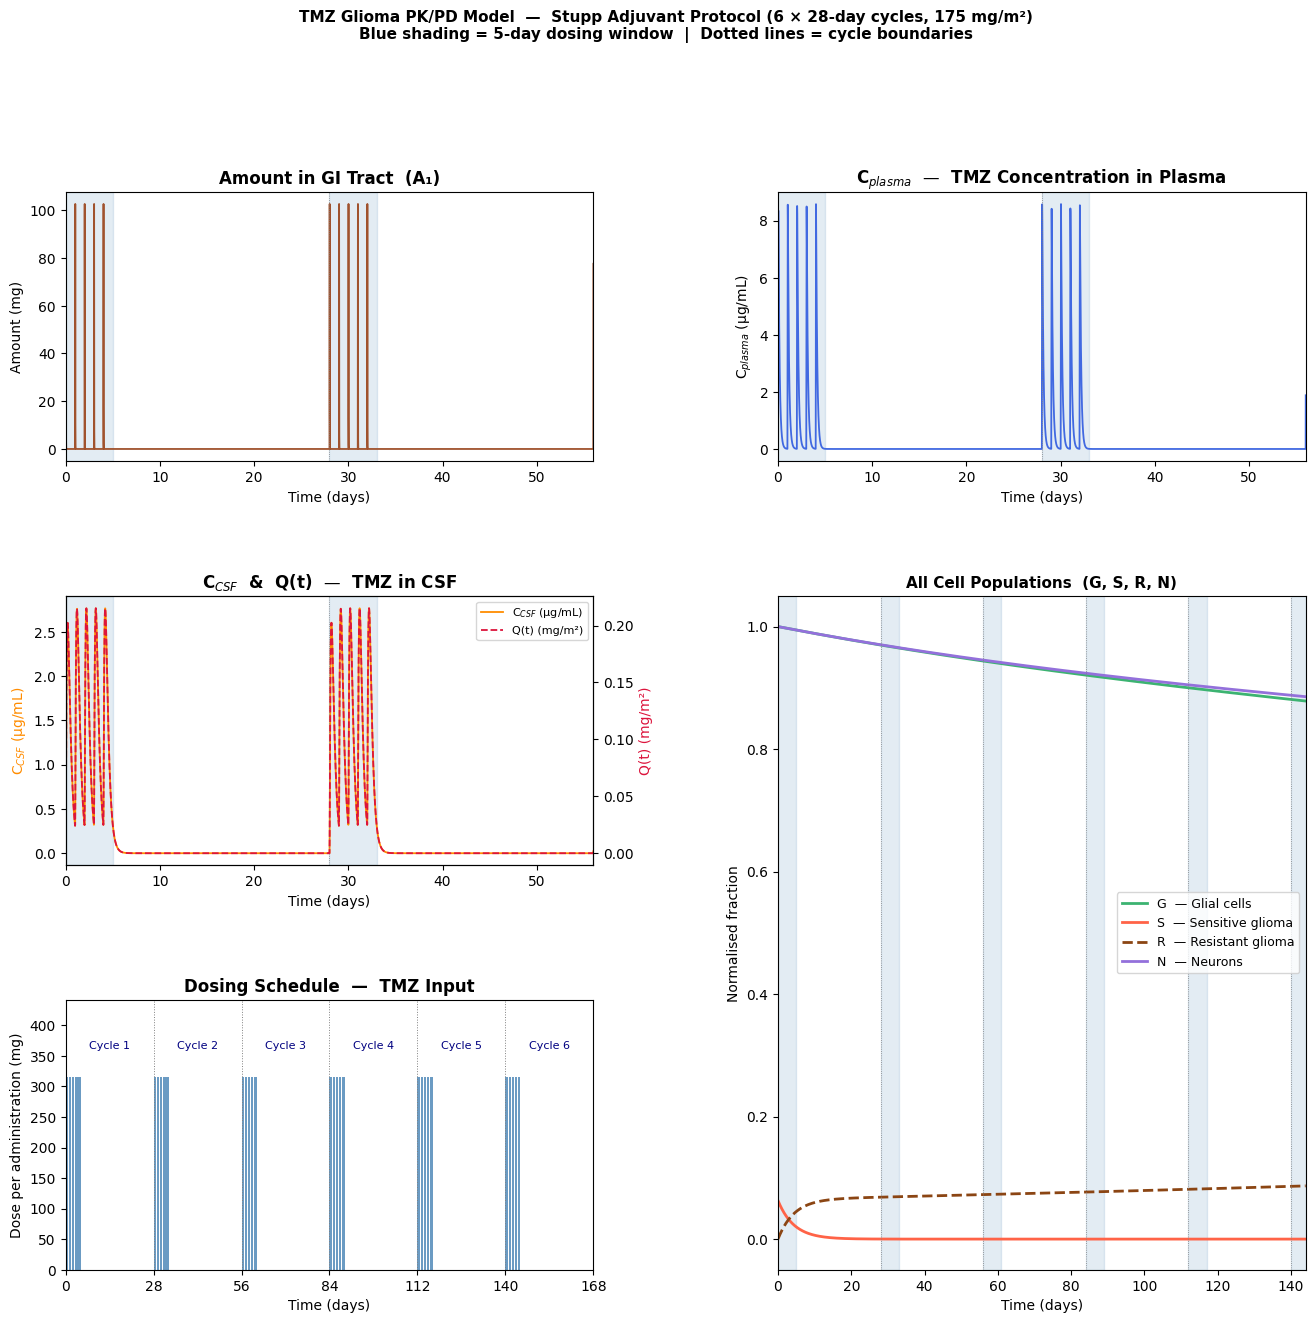

In [69]:
"""
Temozolomide (TMZ) Glioma PK/PD Model
======================================
Combines:
  - 3-compartment PK model (GI tract → Plasma → CSF)
  - Normalised glioma cell population dynamics (glial, sensitive, resistant, neurons)

Dosing: Stupp Protocol (post-radiotherapy adjuvant phase)
  6 cycles × 5 days on / 23 days off, 175 mg/m² per day
  Assumed body surface area (BSA) = 1.8 m² → dose = 315 mg per administration
"""

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ─────────────────────────────────────────────
# PK PARAMETERS
# ─────────────────────────────────────────────
Ka  = 5.8          # h⁻¹  absorption rate constant (GI → plasma)
CL  = 10.0         # L/h  oral clearance
VD  = 30.3         # L    volume of distribution (plasma)
Vp  = 0.14         # L    volume of distribution (CSF)
k23 = 7.2e-4       # h⁻¹  plasma → CSF transfer rate
k32 = 0.14         # h⁻¹  CSF → plasma transfer rate

# ─────────────────────────────────────────────
# DOSING SCHEDULE  (Stupp adjuvant protocol)
# ─────────────────────────────────────────────
BSA          = 1.8          # m²  (typical adult)
DOSE_PER_M2  = 175          # mg/m²
DOSE         = DOSE_PER_M2 * BSA   # mg per administration

N_CYCLES     = 6
DAYS_ON      = 5
CYCLE_LENGTH = 28           # days
DIAGNOSE_HOURS= 0 # A function that can be used to delay the dosing schedule

# Build list of dose times (hours)
dose_times_h = []
for cycle in range(N_CYCLES):
    cycle_start = cycle * CYCLE_LENGTH * 24 + DIAGNOSE_HOURS  # hours
    for day in range(DAYS_ON):
        dose_times_h.append(cycle_start + day * 24.0)

dose_times_h = np.array(dose_times_h)
T_END_H = dose_times_h[-1] + 1     # total simulation time in hours

# ─────────────────────────────────────────────
# CELL BIOLOGY PARAMETERS  (normalised model)
# ─────────────────────────────────────────────
Pg   = 0.0068 / 24   # day⁻¹ → h⁻¹  glial growth rate
Ps   = 0.012  / 24   # h⁻¹           sensitive glioma growth rate
Pr   = 0.004  / 24   # h⁻¹           resistant glioma growth rate (mid-range)

beta1 = 1.8e-2 / 24  # h⁻¹  glial competition coefficient
beta2 = 1.8e-3 / 24  # h⁻¹  sensitive competition coefficient
beta3 = 1.8e-3 / 24  # h⁻¹  resistant competition coefficient

alpha  = 1.0         # neuronal influence scaling
alpha1 = alpha2 = alpha3 = 1.0

i1 = 4.7e-8/24          # m²/(mg·h)  chemo effect on glial
i2 = 4.7e-5/24          # m²/(mg·h)  chemo effect on sensitive glioma
i3 = 4.7e-8/24          # m²/(mg·h)  chemo effect on neurons

a1 = a2 = a3 = 1.0   # half-saturation constants (normalised)

u  = 0.01            # mutation rate (0–1); fraction of sensitive → resistant per unit Q
zeta = 0.2 / 24      # h⁻¹  drug elimination from tissue

# ─────────────────────────────────────────────
# HELPER FUNCTIONS
# ─────────────────────────────────────────────
def F(x):
    """Heaviside step: 0 if x ≤ 0, else 1."""
    return 1.0 if x > 0 else 0.0

def Q_csf_mgm2(C_csf_ugmL):
    """Convert CSF concentration (µg/mL) → mg/m² using the paper's scaling."""
    return (140.0 / 1800.0) * C_csf_ugmL

def dose_input(t, dose_list, dose_amount, duration=0.5):
    """
    Returns instantaneous infusion rate (mg/h) at time t.
    Each dose is modelled as a short square pulse of `duration` hours.
    """
    for td in dose_list:
        if td <= t < td + duration:
            return dose_amount / duration
    return 0.0

# ─────────────────────────────────────────────
# ODE SYSTEM
# ─────────────────────────────────────────────
def model(t, y):
    A1, A2, A3, g, s, r, n = y

    # ── PK ──────────────────────────────────
    D_rate = dose_input(t, dose_times_h, DOSE)   # mg/h delivered to GI tract

    dA1 = D_rate - Ka * A1
    dA2 = Ka * A1 - (CL / VD) * A2 - k23 * A2 + k32 * A3 * (Vp / 1.0)
    dA3 = k23 * A2 - k32 * A3

    C_plasma = A2 / VD                           # µg/mL  (mg/L ≡ µg/mL)
    C_csf    = A3 / Vp                           # µg/mL
    Q        = Q_csf_mgm2(C_csf)                # mg/m²  — drug in tissue

    # ── Cell dynamics (normalised model) ────
    # Glial cells
    dg = (Pg * g * (1 - g)
          - beta1 * g * (s + r)
          - (i1 * g * Q) / (a1 + g))

    # Sensitive glioma
    ds = (Ps * s * (1 - (s + r))
          - beta2 * g * s
          - u * F(Q) * s
          - (i2 * s * Q) / (a2 + s))

    # Resistant glioma
    dr = (Pr * r * (1 - (s + r))
          - beta3 * g * r
          + u * F(Q) * s)

    # Neurons
    g_dot = (Pg * g * (1 - g)
             - beta1 * g * (s + r)
             - (i1 * g * Q) / (a1 + g))   # reuse dg as g_dot
    dn = (alpha * g_dot * F(-g_dot) * n
          - (i3 * n * Q) / (a3 + n))

    return [dA1, dA2, dA3, dg, ds, dr, dn]

# ─────────────────────────────────────────────
# INITIAL CONDITIONS
# ─────────────────────────────────────────────
# PK compartments start empty
A1_0 = A2_0 = A3_0 = 0.0

# Normalised cell fractions at t=0 (post-radiotherapy state)
g0 = 1    # glial cells near carrying capacity
s0 = 0.0629  # small residual sensitive tumour
r0 = 0  # small resistant population
n0 = 1    # neurons somewhat depleted by prior treatment

y0 = [A1_0, A2_0, A3_0, g0, s0, r0, n0]

# ─────────────────────────────────────────────
# SOLVE
# ─────────────────────────────────────────────
t_eval_base = np.linspace(0, T_END_H, 10_000)

# Forces evaluation at the start and end of every 0.5h dose window (OTHERWISE delayed dosing schedules would NOT work!)
dose_window_times = np.concatenate([
    dose_times_h,
    np.array(dose_times_h) + 0.5
])

t_eval = np.sort(np.unique(np.concatenate([t_eval_base, dose_window_times])))

sol = solve_ivp(
    model,
    [0, T_END_H],
    y0,
    method='RK45',
    t_eval=t_eval,
    rtol=1e-8,
    atol=1e-10,
    dense_output=True,
    max_step=0.1
)

t_days = sol.t / 24.0
A1, A2, A3, g, s, r, n = sol.y

C_plasma = A2 / VD
C_csf    = A3 / Vp
Q_tissue = Q_csf_mgm2(C_csf)

# ─────────────────────────────────────────────
# PLOTTING
# ─────────────────────────────────────────────

# Show only first 2 cycles for PK plots so dosing fluctuations are clearly visible
PK_ZOOM_DAYS = 2 * CYCLE_LENGTH   # 56 days

cycle_boundaries = [c * CYCLE_LENGTH for c in range(N_CYCLES + 1)]

def shade_cycles(ax, x_end):
    for c in range(N_CYCLES):
        start = c * CYCLE_LENGTH
        if start >= x_end:
            break
        end = min(start + DAYS_ON, x_end)
        ax.axvspan(start, end, alpha=0.15, color='steelblue', label='_nolegend_')

def add_cycle_lines(ax, x_end):
    for cb in cycle_boundaries[1:]:
        if cb <= x_end:
            ax.axvline(cb, color='grey', lw=0.6, ls=':')

fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.50, wspace=0.35)

# ── 1. Amount in GI Tract (A1) ───────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(t_days, A1, color='sienna', lw=1.3)
shade_cycles(ax1, PK_ZOOM_DAYS)
add_cycle_lines(ax1, PK_ZOOM_DAYS)
ax1.set_title('Amount in GI Tract  (A₁)', fontweight='bold')
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Amount (mg)')
ax1.set_xlim(0, PK_ZOOM_DAYS)

# ── 2. Amount in Plasma (A2) → Cplasma ───────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(t_days, C_plasma, color='royalblue', lw=1.3)
shade_cycles(ax2, PK_ZOOM_DAYS)
add_cycle_lines(ax2, PK_ZOOM_DAYS)
ax2.set_title('C$_{plasma}$  —  TMZ Concentration in Plasma', fontweight='bold')
ax2.set_xlabel('Time (days)')
ax2.set_ylabel('C$_{plasma}$ (µg/mL)')
ax2.set_xlim(0, PK_ZOOM_DAYS)

# ── 3. Amount in CSF (A3) → Ccsf & Q(t) ─────
ax3 = fig.add_subplot(gs[1, 0])
ax3_r = ax3.twinx()
ax3.plot(t_days, C_csf,    color='darkorange', lw=1.3, label='C$_{CSF}$ (µg/mL)')
ax3_r.plot(t_days, Q_tissue, color='crimson',  lw=1.3, ls='--', label='Q(t) (mg/m²)')
shade_cycles(ax3, PK_ZOOM_DAYS)
add_cycle_lines(ax3, PK_ZOOM_DAYS)
ax3.set_title('C$_{CSF}$  &  Q(t)  —  TMZ in CSF', fontweight='bold')
ax3.set_xlabel('Time (days)')
ax3.set_ylabel('C$_{CSF}$ (µg/mL)', color='darkorange')
ax3_r.set_ylabel('Q(t) (mg/m²)',     color='crimson')
ax3.set_xlim(0, PK_ZOOM_DAYS)
lines1, labs1 = ax3.get_legend_handles_labels()
lines2, labs2 = ax3_r.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc='upper right')

# ── 4. All cell populations on one graph ─────
ax4 = fig.add_subplot(gs[1:, 1])   # spans rows 1 and 2, right column
ax4.plot(t_days, g, color='mediumseagreen', lw=2.0, label='G  — Glial cells')
ax4.plot(t_days, s, color='tomato',         lw=2.0, label='S  — Sensitive glioma')
ax4.plot(t_days, r, color='saddlebrown',    lw=2.0, label='R  — Resistant glioma', ls='--')
ax4.plot(t_days, n, color='mediumpurple',   lw=2.0, label='N  — Neurons')
shade_cycles(ax4, t_days[-1])
add_cycle_lines(ax4, t_days[-1])
ax4.set_title('All Cell Populations  (G, S, R, N)', fontweight='bold', fontsize=11)
ax4.set_xlabel('Time (days)')
ax4.set_ylabel('Normalised fraction')
ax4.set_xlim(0, t_days[-1])
ax4.legend(fontsize=9, loc='center right')

# ── 5. Dosing schedule bar chart (all 6 cycles) ──
ax5 = fig.add_subplot(gs[2, 0])
dose_day_list = [td / 24.0 for td in dose_times_h]
ax5.bar(dose_day_list, [DOSE] * len(dose_day_list),
        width=0.8, color='steelblue', alpha=0.8, align='edge')
for cb in cycle_boundaries[1:]:
    ax5.axvline(cb, color='grey', lw=0.7, ls=':')
ax5.set_title('Dosing Schedule  —  TMZ Input', fontweight='bold')
ax5.set_xlabel('Time (days)')
ax5.set_ylabel('Dose per administration (mg)')
ax5.set_xlim(0, t_days[-1])
ax5.set_xticks(cycle_boundaries)
ax5.set_ylim(0, DOSE * 1.4)

# Annotate cycle numbers
for c in range(N_CYCLES):
    mid = c * CYCLE_LENGTH + CYCLE_LENGTH / 2
    ax5.text(mid, DOSE * 1.15, f'Cycle {c+1}', ha='center', fontsize=8, color='navy')

fig.suptitle(
    'TMZ Glioma PK/PD Model  —  Stupp Adjuvant Protocol (6 × 28-day cycles, 175 mg/m²)\n'
    'Blue shading = 5-day dosing window  |  Dotted lines = cycle boundaries',
    fontsize=11, fontweight='bold', y=1.01
)


print("Simulation complete.")
print(f"  Peak plasma TMZ : {C_plasma.max():.3f} µg/mL")
print(f"  Peak CSF TMZ    : {C_csf.max():.4f} µg/mL")
print(f"  Final sensitive : {s[-1]:.4f} (normalised fraction)")
print(f"  Final resistant : {r[-1]:.4f} (normalised fraction)")
print(f"  Final neurons   : {n[-1]:.4f} (normalised fraction)")